# NFL Combine EDA — Dataset: nfl_combine_2010_to_2023.csv

Columns: Year, Player, Pos, School, Height, Weight, 40yd, Vertical, Bench, Broad Jump, 3Cone, Shuttle, Drafted, Round, Pick

In [2]:
# Setup
# Ensure nbformat >= 4.2.0 for Plotly/MIME rendering in the notebook
try:
    import nbformat
    v = getattr(nbformat, "__version__", "0")
    if tuple(map(int, (v.split(".") + ["0", "0"])[:2])) < (4, 2):
        raise ImportError("nbformat too old")
except (ImportError, Exception):
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat>=4.2.0"], capture_output=True)
    import nbformat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

np.random.seed(42)
OUTPUT_DIR = Path("combine_eda_plots")
OUTPUT_DIR.mkdir(exist_ok=True)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

In [3]:
# Load nfl_combine_2010_to_2023.csv and map to standard names
FPATH = "nfl_combine_2010_to_2023.csv"
df = pd.read_csv(FPATH)

# Standardize column names (your CSV: Pos, Height, Weight, Broad Jump, 3Cone)
df = df.rename(columns={
    "Pos": "Position",
    "Height": "Height_raw",
    "Weight": "Weight_lbs",
    "Broad Jump": "Broad",
    "3Cone": "ThreeCone",
})
# Keep: Year, Player, School, 40yd, Vertical, Bench, Shuttle, Drafted, Round, Pick

# Parse Height first (before coercing): "6-3" -> 75 inches
def parse_height(h):
    if pd.isna(h): return np.nan
    if isinstance(h, (int, float)) and 50 < h < 100: return float(h)
    s = str(h).strip()
    if "-" in s:
        parts = s.split("-")
        if len(parts) == 2:
            try: return int(parts[0]) * 12 + int(parts[1])
            except ValueError: return np.nan
    return pd.to_numeric(h, errors="coerce")

df["Height_in"] = df["Height_raw"].apply(parse_height)
# Coerce other numerics (do not coerce Height_raw so "6-3" stays for any re-parse)
for c in ["Weight_lbs", "40yd", "Vertical", "Bench", "Broad", "ThreeCone", "Shuttle"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
# If Height_in still missing where we had a value, try numeric on raw
mask = df["Height_in"].isna() & df["Height_raw"].notna()
df.loc[mask, "Height_in"] = pd.to_numeric(df.loc[mask, "Height_raw"], errors="coerce")

# Filter to post-2010
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).query("Year >= 2010").copy()

# Impute missing combine metrics by position (mean per position)
def impute_by_position(ser, positions):
    out = ser.copy()
    for pos in positions.unique():
        idx = positions == pos
        g = ser.loc[idx]
        if g.notna().sum() > 0:
            out.loc[idx] = g.fillna(g.mean())
    return out

if "Position" in df.columns:
    for col in ["40yd", "Vertical", "Broad", "Bench", "ThreeCone", "Shuttle", "Height_in", "Weight_lbs"]:
        if col in df.columns and df[col].isna().any():
            df[col] = impute_by_position(df[col], df["Position"])

# Derived columns
weight_kg = df["Weight_lbs"] / 2.2
forty_sec = df["40yd"].replace(0, np.nan)
df["Speed_Score"] = weight_kg * (100 / forty_sec) ** 3
df["Explosiveness"] = df["Vertical"].fillna(0) + (df["Broad"].fillna(0) / 12)

POSITION_GROUP = {"T": "OL", "OG": "OL", "C": "OL", "WR": "Skill", "RB": "Skill", "TE": "Skill",
    "CB": "DB", "S": "DB", "SS": "DB", "FS": "DB", "DE": "Big Skill", "DT": "Big Skill", "EDGE": "Big Skill", "NT": "Big Skill",
    "LB": "LB", "ILB": "LB", "OLB": "LB", "P": "Other", "K": "Other"}
df["Position_Group"] = df["Position"].map(POSITION_GROUP).fillna("Other")

# Position percentiles (lower 40yd / ThreeCone / Shuttle = better)
for m in ["40yd", "Vertical", "Broad", "Bench", "ThreeCone", "Shuttle"]:
    if m not in df.columns: continue
    asc = m in ["40yd", "ThreeCone", "Shuttle"]
    df[f"{m}_pct"] = df.groupby("Position", group_keys=False)[m].apply(lambda s: s.rank(pct=True, ascending=asc))

# Outlier flag (>3 SD from position mean)
metrics = [c for c in ["40yd", "Vertical", "Broad", "Bench", "ThreeCone", "Shuttle"] if c in df.columns]
df["Outlier_Flag"] = False
for m in metrics:
    pos_mean = df.groupby("Position")[m].transform("mean")
    pos_std = df.groupby("Position")[m].transform("std").replace(0, np.nan)
    z = np.abs((df[m] - pos_mean) / pos_std)
    df.loc[z > 3, "Outlier_Flag"] = True

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (4741, 26)
Columns: ['Year', 'Player', 'Position', 'School', 'Height_raw', 'Weight_lbs', '40yd', 'Vertical', 'Bench', 'Broad', 'ThreeCone', 'Shuttle', 'Drafted', 'Round', 'Pick', 'Height_in', 'Speed_Score', 'Explosiveness', 'Position_Group', '40yd_pct', 'Vertical_pct', 'Broad_pct', 'Bench_pct', 'ThreeCone_pct', 'Shuttle_pct', 'Outlier_Flag']


,Year,Player,Position,School,Height_raw,Weight_lbs,40yd,Vertical,Bench,Broad,...,Speed_Score,Explosiveness,Position_Group,40yd_pct,Vertical_pct,Broad_pct,Bench_pct,ThreeCone_pct,Shuttle_pct,Outlier_Flag
0,2010,Seyi Ajirotutu,WR,Fresno State,6-3,204.0,4.60,36.000000,14.000000,115.000000,...,9.526514e+05,45.583333,Skill,0.839552,0.352985,0.897761,0.672388,0.933582,0.874627,False
1,2010,Rahim Alem,DE,LSU,6-3,251.0,4.75,30.500000,23.517766,106.000000,...,1.064560e+06,39.333333,Big Skill,0.295019,0.818008,0.952107,0.496169,0.938697,0.992337,False
2,2010,Charles Alexander,DT,LSU,6-4,300.0,5.40,28.986239,27.473430,105.000000,...,8.659988e+05,37.736239,Big Skill,0.952632,0.533333,0.505263,0.489474,0.501754,0.519298,False
3,2010,Danario Alexander,WR,Missouri,6-5,215.0,4.62,35.390328,14.402597,121.816112,...,9.910370e+05,45.541671,Skill,0.882090,0.507463,0.507463,0.479851,0.500746,0.511940,False
4,2010,Nate Allen,S,South Florida,6-0,207.0,4.50,35.272541,16.000000,121.553279,...,1.032548e+06,45.401981,DB,0.258170,0.482026,0.488562,0.687908,0.488562,0.506536,False


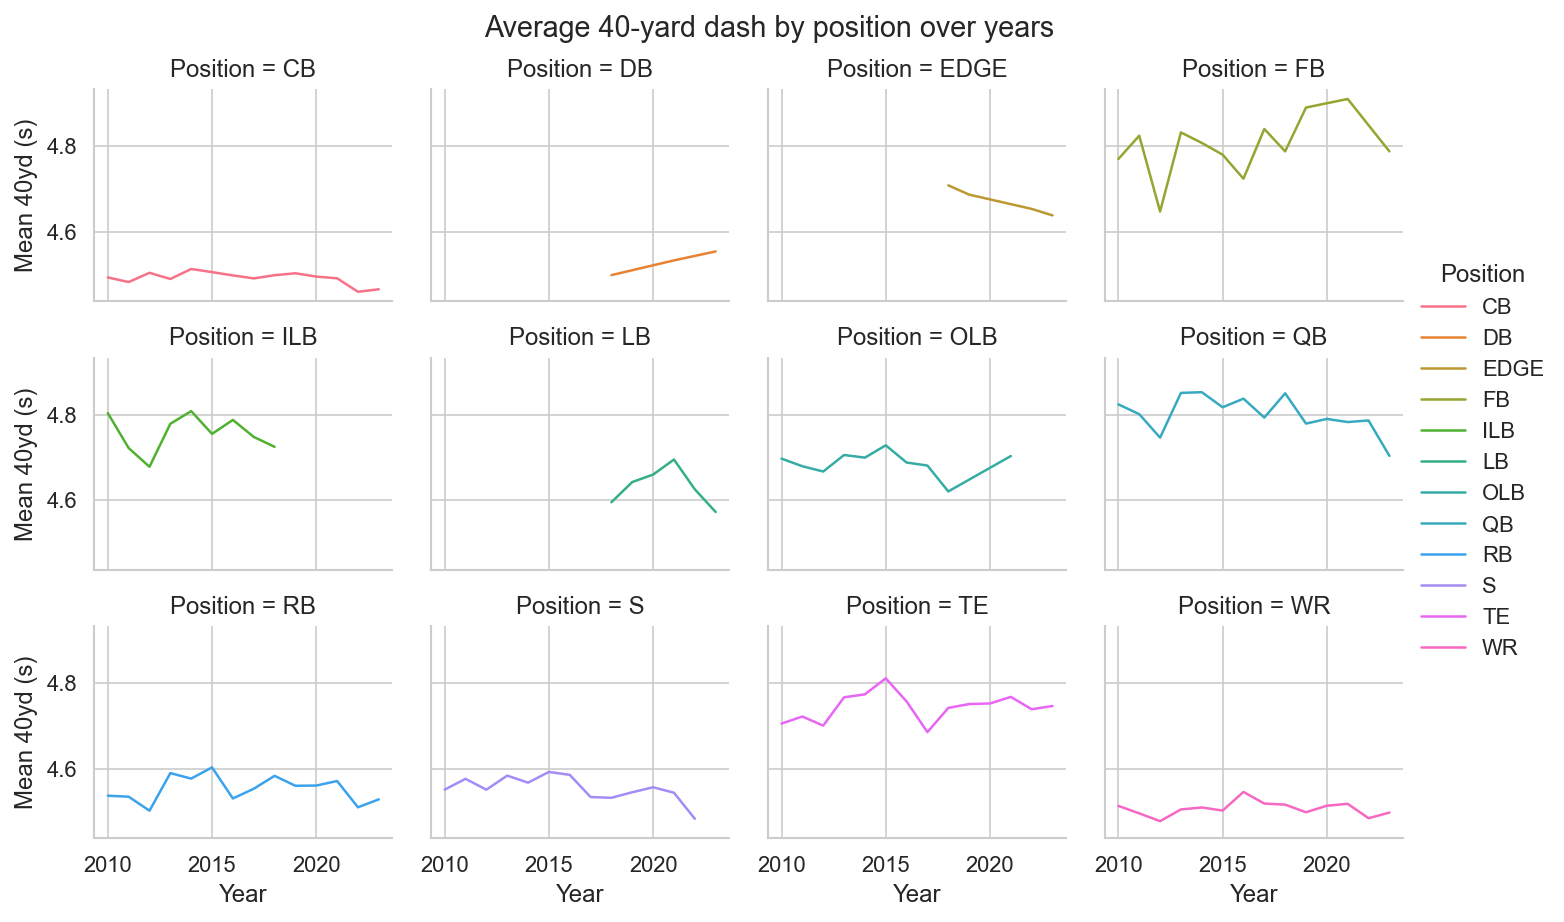

In [4]:
# --- Plot 8: Small multiples — Mean 40yd by position over years (2010–2025) ---
def plot_40yd_by_year(df, out_dir):
    if "Year" not in df.columns or "40yd" not in df.columns: return
    agg = df.groupby(["Position", "Year"])["40yd"].mean().reset_index()
    positions = agg.groupby("Position")["40yd"].agg("mean").sort_values().index[:12]
    agg = agg[agg["Position"].isin(positions)]
    g = sns.relplot(data=agg, x="Year", y="40yd", hue="Position", kind="line", col="Position", col_wrap=4, height=2, aspect=1.2)
    g.set_axis_labels("Year", "Mean 40yd (s)")
    g.fig.suptitle("Average 40-yard dash by position over years", y=1.02)
    g.savefig(out_dir / "08_40yd_by_year.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_40yd_by_year(df, OUTPUT_DIR)

## Spider charts: 2020 combine — Individual players by position

**6 radar charts total:** separate charts for **drafted** and **non-drafted** players. For each of the 3 positions (QB, WR, CB), one chart shows all **drafted** players (one line per player) and one chart shows all **non-drafted** players (one line per player). No overall score; metrics normalized 0–100 within each chart (higher = better).

In [9]:
# Spider charts: individual PLAYERS — separate charts for drafted and for non-drafted (2020 combine)
# 10 charts total: 5 positions × 2 (drafted | non-drafted). Each chart = one line per player at that position.

import plotly.graph_objects as go

SPIDER_POSITIONS = ["QB", "WR", "CB"]
METRICS_HIGHER_BETTER = ["Height_in", "Weight_lbs", "Vertical", "Bench", "Broad"]
METRICS_LOWER_BETTER = ["40yd", "ThreeCone", "Shuttle"]
SPIDER_METRICS = METRICS_HIGHER_BETTER + METRICS_LOWER_BETTER
THETA_LABELS = {"Height_in": "Height", "Weight_lbs": "Weight", "40yd": "40 yd", "ThreeCone": "3-Cone"}

def _normalize_players(players_df, metric_cols, higher_better_cols):
    """Normalize each column across players to 0–100; higher = better for higher_better_cols."""
    norm = players_df[metric_cols].copy()
    for c in metric_cols:
        s = norm[c].dropna()
        if s.empty or s.min() == s.max():
            norm[c] = 50.0
            continue
        lo, hi = s.min(), s.max()
        scaled = (norm[c] - lo) / (hi - lo) * 100
        if c not in higher_better_cols:
            scaled = 100 - scaled  # faster time -> higher score
        norm[c] = scaled.fillna(50)
    return norm

def plot_spider_players(df, position, drafted_flag, out_dir):
    """One radar chart: one line per player at this position, either all drafted or all non-drafted (2020)."""
    d = df[df["Year"] == 2020].copy()
    d["SpiderPos"] = d["Position"].replace({"DE": "EDGE", "EDGE": "EDGE"})
    d = d[(d["SpiderPos"] == position) & (d["Drafted"] == drafted_flag)]
    cols = [c for c in SPIDER_METRICS if c in d.columns]
    if d.empty or not cols:
        print(f"Skip {position} (drafted={drafted_flag}): no data")
        return
    # Normalize metrics across these players (0–100 per metric)
    norm = _normalize_players(d, cols, METRICS_HIGHER_BETTER)
    norm["Player"] = d["Player"].values
    metric_order = cols
    theta_labels = [THETA_LABELS.get(c, c.replace("_", " ")) for c in metric_order]

    fig = go.Figure()
    for _, row in norm.iterrows():
        name = row["Player"]
        r = [row[c] for c in metric_order]
        r = r + [r[0]]
        theta = theta_labels + [theta_labels[0]]
        fig.add_trace(go.Scatterpolar(r=r, theta=theta, name=name))
    label = "Drafted" if drafted_flag else "Non-drafted"
    fig.update_layout(
        title=f"2020 combine — {position} ({label})",
        polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
        showlegend=True,
        template="plotly_white",
        legend=dict(orientation="v", yanchor="top", y=1, xanchor="left"),
    )
    fname = f"spider_2020_{position}_{'drafted' if drafted_flag else 'nondrafted'}_players.html"
    fig.write_html(str(out_dir / fname))
    fig.show()

# 6 charts: for each position (QB, WR, CB), one chart for drafted and one for non-drafted players (individuals)
for pos in SPIDER_POSITIONS:
    plot_spider_players(df, pos, drafted_flag=True, out_dir=OUTPUT_DIR)
    plot_spider_players(df, pos, drafted_flag=False, out_dir=OUTPUT_DIR)